# Assignment: Amazon Sales Dataset — EDA, Feature Engineering & Basic Modeling

**Dataset:** [Amazon Sales Dataset on Kaggle](https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset) — file `amazon.csv` (~1,465 rows, 16 columns).

**Total marks:** 100 (+10 bonus) · **Estimated effort:** 8–10 hours

**Instructions**
- Answer every question in the cells provided. Add more cells if you need them.
- Every plot needs a title, labelled axes (with units) and 1–2 sentences of interpretation below it.
- Use `random_state=42` wherever randomness is involved.
- The notebook must run top-to-bottom without errors before submission.
- Disclose any AI-tool use in the final cell.

**Name:** Kaushal Kumar· **Roll no.:** 3120251026

## Setup
Import the libraries you need and list their versions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Add further imports here (scikit-learn, nltk/textblob, etc.)

## Dataset columns

| Column | Meaning | Raw format / notes |
| --- | --- | --- |
| product_id | Amazon ASIN | String; some IDs repeat |
| product_name | Listing title | Free text |
| category | Category path | Pipe-separated (`\|`) |
| discounted_price | Selling price (₹) | String with `₹` and commas |
| actual_price | List price (₹) | String with `₹` and commas |
| discount_percentage | Discount | String like `64%` |
| rating | Average star rating | String; contains an invalid value |
| rating_count | Number of ratings | String with commas; a few missing |
| about_product | Product description | Free text |
| user_id, user_name | Reviewers | Comma-separated lists |
| review_id, review_title, review_content | Reviews | Comma-separated lists |
| img_link, product_link | URLs | Not needed for modeling |

# Part A — Data loading and cleaning (15 marks)
Produce a clean DataFrame `df_clean` and justify every cleaning decision in a markdown cell.

**A1 (2 marks).** Load `amazon.csv` and report its shape, dtypes, `head()` and memory usage.

In [ ]:
df = pd.read_csv('D:/Pine_labs_Assignment/Pine_lab_assignment/amazon.csv')
df.head()  # Loading dataset

In [ ]:
print(f"Shape of the dataset: {df.shape}")  # Checking the shape of the dataset

**observation:**
The dataset contains 1465 rows and 16 columns.

In [ ]:
df.info() # Checking the information about the dataset

**Observation:**  
All 16 features are currently stored as `object` datatype, and the
DataFrame uses approximately 183.3 KB of memory.

-----------------------------------------------------------------------------------------------------------------

**A2 (3 marks).** Convert `discounted_price` and `actual_price` to floats by stripping `₹` and commas. Convert `discount_percentage` to a float between 0 and 1.

In [ ]:
df_copy = df.copy()  # Creating a copy of the original dataframe to avoid modifying it directly
df_copy['discounted_price'] = (
    df_copy['discounted_price']
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype(float)
)

df_copy['actual_price'] = (
    df_copy['actual_price']
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype(float)
)

df_copy['discount_percentage'] = (
    df_copy['discount_percentage']
    .str.replace("%", "")
    .astype(float) / 100
)

### Observation

A copy of the original dataset is created to preserve the original data while performing the required cleaning operations.

- **`discounted_price` and `actual_price`**: The `₹` currency symbol and commas are removed using str and replace, and the values are converted from strings to `float`.
- **`discount_percentage`**: The `%` symbol is removed and the values are converted to `float` using str and replace. The values are then divided by 100 to represent the discount as a proportion between 0 and 1.

These transformations convert the relevant variables into numerical formats suitable for further analysis.

-----------------------------------------------------------------------------------------------------------------

**A3 (2 marks).** Convert `rating` to float. Find the invalid value(s) and explain what you did with them (drop, impute or look up) and why.

In [ ]:
df_copy['rating'].value_counts()

In [ ]:
df_copy['rating'].isnull().sum() # Checking for missing values in the 'rating' column

In [ ]:
df_copy[df_copy['rating'] == "|"] # Checking for invalid ratings

In [ ]:
df_copy[~(df_copy['rating'] == "|")]['rating'].astype(float).describe() # Descriptive statistics for valid ratings

In [ ]:
df_copy.loc[df_copy['rating'] == "|", 'rating'] = df_copy[~(df_copy['rating'] == "|")]['rating'].astype(float).median()

In [ ]:
df_copy['rating'] = df_copy['rating'].astype(float)  # Converting rating to float

**Treatment of the Invalid Value:**  

The `rating` column contained one invalid value represented by `|`. Although the actual rating of **3.8** was available through the product link, I deliberately did not use it. In a real-world modelling setting, such external information may not always be available at the time of analysis. Therefore, to simulate a realistic modelling scenario, I restricted the imputation to the information available within the dataset itself and replaced the invalid value with the median of the valid numerical ratings. This approach avoids introducing external information that may not be consistently available for other observations.

----------------------------------------------------------------------------------------------------------------

**A4 (2 marks).** Convert `rating_count` to integer. Report how many values are missing and choose a handling strategy.

In [ ]:
df_copy['rating_count'].isna().sum()  # Checking the missing values in the 'rating_count' column

In [ ]:
df_copy[df_copy['rating_count'].isnull()]

In [ ]:
df_copy['rating_count'].str.replace(',', '').astype(float).describe() # Descriptive statistics for valid rating_count values

In [ ]:
df_copy['rating_count'] = pd.to_numeric(
    df_copy['rating_count'].str.replace(',', '', regex=False),
    errors='coerce'
)

In [ ]:
df_copy['rating_count'].dtype

In [ ]:
# Median rating_count for products with rating 3
median_rating_count_3 = df_copy.loc[
    (df_copy['rating'] == 3.0) & df_copy['rating_count'].notna(),
    'rating_count'
].median()

# Impute missing rating_count for products with rating 3
df_copy.loc[
    (df_copy['rating'] == 3.0) & df_copy['rating_count'].isna(),
    'rating_count'
] = median_rating_count_3


# Median rating_count for products with rating 5
median_rating_count_5 = df_copy.loc[
    (df_copy['rating'] == 5.0) & df_copy['rating_count'].notna(),
    'rating_count'
].median()

# Impute missing rating_count for products with rating 5
df_copy.loc[
    (df_copy['rating'] == 5.0) & df_copy['rating_count'].isna(),
    'rating_count'
] = median_rating_count_5

In [ ]:
df_copy[df_copy['rating_count'].isnull()]

In [ ]:
df_copy['rating_count'] = df_copy['rating_count'].astype(int)

**Treatment of Missing Values:**

There were only two missing values in the `rating_count` column. I first checked the product links available in the dataset to understand the missing observations. Although the actual rating counts could be obtained from Amazon, I **did not use this external information for imputation**. Instead, I restricted the imputation to information available within the dataset to simulate a realistic modelling scenario where external information may not be available.

For the missing observation corresponding to a **rating of 3.0**, I used the median `rating_count` of all other products with a rating of 3.0. Similarly, for the missing observation corresponding to a **rating of 5.0**, I used the median `rating_count` of other products with a rating of 5.0.

I used the **median rather than the mean** because `rating_count` is highly skewed and contains products with very large numbers of ratings. The median is less sensitive to these extreme values and therefore provides a more robust estimate for imputation.

Thus, both missing values were imputed using only information contained within the dataset, without incorporating externally verified values from the internet.

-----------------------------------------------------------------------------------------------------------------

**A5 (3 marks).** Check for duplicates: full-row duplicates and repeated `product_id`s. Decide which rows to keep and state your rule.

In [ ]:

df_copy.duplicated().sum()  # Checking for duplicate rows in the dataset

In [ ]:
df_copy['product_id'].duplicated().sum() # Checking for duplicate product IDs in the dataset

In [ ]:
df_copy[df_copy['product_id'].duplicated()]

In [ ]:
df_copy.iloc[1] == df_copy.iloc[377]  # Checking if the duplicate rows are identical

In [ ]:
df_copy[df_copy['product_id'] == "B098NS6PVG"]

**Observation:**

The `img_link` and `product_link` columns may contain different URLs even when they refer to the same Amazon product. These URL differences can cause otherwise identical observations to be treated as non-duplicate rows when checking for complete row duplication. Therefore, I removed `img_link` and `product_link` from the duplicate analysis so that duplicate rows are identified based on the actual product and review-related information rather than differences in URL parameters.

In [ ]:
df_copy.drop(columns = ['img_link','product_link'], inplace=True)  # Dropping unnecessary columns

In [ ]:
df_copy.duplicated().sum()

In [ ]:
df_copy.drop_duplicates(keep='first', inplace=True)  # Dropping duplicate rows, keeping the first occurrence

**Observation:**

After removing the `img_link` and `product_link` columns, which could create differences in otherwise identical rows due to variations in URL parameters, **65 exact duplicate rows** are identified. This provides a more accurate assessment of duplicate observations based on the substantive product and review information rather than differences in the URLs.

In [ ]:
df_copy['product_id'].duplicated().sum()

In [ ]:
df_duplicated = df_copy[df_copy['product_id'].duplicated(keep=False)].sort_values('product_id')  # Displaying all duplicate product IDs
df_duplicated[['product_id', 'rating_count']]

In [ ]:
duplicate_analysis = []

for product_id, group in df_duplicated.groupby('product_id'):
    differing_cols = group.columns[
        group.nunique(dropna=False) > 1
    ].tolist()

    duplicate_analysis.append({
        'product_id': product_id,
        'number_of_rows': len(group),
        'different_columns': differing_cols
    })

duplicate_analysis = pd.DataFrame(duplicate_analysis)

duplicate_analysis

In [ ]:
only_rating_count = duplicate_analysis[
    duplicate_analysis['different_columns'].apply(
        lambda x: x == ['rating_count']
    )
]

only_rating_count

In [ ]:
only_rating_count = only_rating_count['product_id']

df_copy.loc[
    df_copy['product_id'].isin(only_rating_count),
    'rating_count'
] = (
    df_copy.loc[
        df_copy['product_id'].isin(only_rating_count)
    ]
    .groupby('product_id')['rating_count']
    .transform('median')
    .round()
)

In [ ]:
df_copy = df_copy.drop_duplicates()

In [ ]:
df_copy.duplicated(subset=['product_id'], keep='first').sum()  # Checking for duplicate product IDs after dropping unnecessary columns

### Observation: Duplicate Observations

Initially, there were **0 exact duplicate rows**, but **114 observations had repeated `product_id` values**. I then removed `img_link` and `product_link` from the duplicate check because small differences in these URLs can make otherwise identical rows look different.

After removing these columns, I found **65 exact duplicate rows** and **49 rows where `product_id` was repeated but the complete rows were not identical**.

I handled them as follows:

1. **65 exact duplicates** → removed.
2. Out of the remaining **49 repeated `product_id` observations**, **23 had only a small difference in `rating_count`**. These were standardized and then treated as duplicates.
3. Rows with differences in **reviews, users, or other product information** were retained, as they represent different observations.
4. Rows with **substantive differences in price or other product-related variables** were also retained.

This way, I removed only observations that could reasonably be treated as duplicates without unnecessarily losing useful information.


-----------------------------------------------------------------------------------------------------------------

**A6 (2 marks).** Sanity checks: confirm `discounted_price <= actual_price`; recompute the discount from the two prices, compare it with `discount_percentage`, and flag mismatches.

In [ ]:
df_copy[df_copy['discounted_price'] > df_copy['actual_price']]

In [ ]:
df_copy['discount_per_rec'] = round(((df_copy['actual_price'] - df_copy['discounted_price'])/ df_copy['actual_price']),2)

In [ ]:
df_copy[df_copy['discount_per_rec'] != df_copy['discount_percentage']]

**Observation:**

No observations have a `discounted_price` greater than the `actual_price`. Two observations show a minor 0.1 percentage-point difference between the reported and recalculated discount percentages, which is negligible and likely due to rounding. Therefore, no observations were dropped or modified.

-----------------------------------------------------------------------------------------------------------------

**A7 (1 mark).** Drop columns you will not use and print the final shape of `df_clean`.

In [ ]:
# Your code here
df_copy.head()

In [ ]:
df_copy.drop(columns = ['discount_per_rec'], inplace=True)  # Dropping unnecessary columns

In [ ]:
df_clean = df_copy.copy() # Creating a clean copy of the dataframe for further analysis

In [ ]:
print(f"The number of rows in the cleaned dataset is: {df_clean.shape[0]}")
print(f"The number of columns in the cleaned dataset is: {df_clean.shape[1]}")

Initially, the dataset contained **1,465 rows**. After removing the `img_link` and `product_link` columns, which were not required for the analysis and could create differences between otherwise identical observations, we were left with **1,400 rows**. After checking the repeated `product_id` values and considering the small differences in `rating_count`, **23 duplicate observations were removed**. Therefore, the final dataset contains **1,377 non-duplicate observations**.


=================================================================================================================

# Part B — Exploratory Data Analysis (25 marks)
Plots without interpretation earn half marks.

## B1. Univariate analysis (7 marks)

**B1.1** Summary statistics for all numeric columns. Comment on mean vs median for prices and `rating_count`.

In [ ]:
df_clean.info()

In [ ]:
round(df_clean[['actual_price','discounted_price','discount_percentage','rating_count','rating']].describe(),2)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Actual Price
sns.kdeplot(x=df_clean['actual_price'], ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Actual Price')
axes[0, 0].set_xlabel('Actual Price (₹)')
axes[0, 0].set_ylabel('Density')

# Discounted Price
sns.kdeplot(x=df_clean['discounted_price'], ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Discounted Price')
axes[0, 1].set_xlabel('Discounted Price (₹)')
axes[0, 1].set_ylabel('Density')

# Rating Count
sns.kdeplot(x=df_clean['rating_count'], ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Rating Count')
axes[1, 0].set_xlabel('Rating Count')
axes[1, 0].set_ylabel('Density')

# Remove the empty bottom-right plot
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

### **B1.1 Summary Statistics and Interpretation**

The price variables show a clear difference between the **mean and median**. For `actual_price`, the mean is **₹5,634.45**, while the median is **₹1,749**. Similarly, for `discounted_price`, the mean is **₹3,257.69**, compared with a median of **₹889**. Since the mean is much higher than the median in both cases, the price distributions are **right-skewed**, with a relatively small number of high-priced products pulling the mean upward.

For `rating_count`, the difference is even larger. The mean is **17,736**, whereas the median is **4,951**. This indicates a strong **right-skew**, where a small number of products have very large numbers of ratings. The maximum rating count of **426,973** compared with the median of 4,951 further supports this.

The **KDE plots also support these findings**, as all three distributions show a clear **long right tail**, indicating that most observations are concentrated at lower values while a smaller number of observations have much higher values.

Overall, the **median is more representative of the typical product** for prices and `rating_count` because it is less affected by extreme values.


--------------------------------------------------------------------------------------------------------------------------------------------------------

**B1.2** Histograms of `actual_price`, `discounted_price` and `rating_count` on both linear and log scales. Which scale is more informative, and why?

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

variables = [
    ('actual_price', 'Actual Price (₹)'),
    ('discounted_price', 'Discounted Price (₹)'),
    ('rating_count', 'Rating Count')
]

for i, (col, xlabel) in enumerate(variables):

    # Linear scale
    sns.histplot(
        x=df_clean[col],
        ax=axes[i, 0],
        bins=30
    )
    axes[i, 0].set_title(f'{xlabel} - Linear Scale')
    axes[i, 0].set_xlabel(xlabel)
    axes[i, 0].set_ylabel('Frequency')

    # Log scale
    sns.histplot(
        x=df_clean[col],
        ax=axes[i, 1],
        bins=30
    )
    axes[i, 1].set_xscale('log')
    axes[i, 1].set_title(f'{xlabel} - Log Scale')
    axes[i, 1].set_xlabel(f'{xlabel} (Log Scale)')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### **B1.2 Histograms and Scale Comparison**

The **linear scale** shows the original distribution clearly, but most observations are concentrated near the lower values, making the right tail difficult to examine.

The **log scale is more informative** for all three variables because it spreads out the lower values and makes the long right tail and extreme observations easier to see. This is especially useful for `rating_count`, which has a very large range.

Therefore, I would use the **log-scale plots for interpretation**, while keeping the linear-scale plots to show the distribution in the original units.


--------------------------------------------------------------------------------------------------------------------------------------------------------

**B1.3** Plot the distribution of `rating`. What fraction of products are rated 4.0 or above? What does this imply for a rating-prediction model?

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(x=df_clean['rating'])

ax.set_title('Distribution of Product Ratings')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Products')

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
fraction_4_or_above = (df_clean['rating'] >= 4.0).mean()

print(f"Fraction of products with a rating of 4.0 or above: {fraction_4_or_above:.2f}")

**Observation**

If a large fraction of products have ratings ≥ 4.0, the target variable is concentrated toward higher ratings. This can make rating prediction more difficult because the model has fewer observations at the lower end and may tend to predict ratings closer to the dominant high-rating range.

--------------------------------------------------------------------------------------------------------------------------------------------------------

**B1.4** Plot the distribution of `discount_percentage`.

In [ ]:
sns.histplot(
    x = df_clean['discount_percentage'])

**Observation:**

The `discount_percentage` distribution is spread across a wide range, but most products have discounts between around **20% and 80%**. The highest concentration is around **50–60% discount**. Very few products have discounts close to **0% or 90%+**. Overall, the distribution is fairly spread out, with no single discount level dominating the dataset.

--------------------------------------------------------------------------------------------------------------------------------------------------------

## B2. Category analysis (6 marks)

**B2.1** Split `category` on `|` and extract the top-level (`main_category`) and last-level (`sub_category`) labels.

In [ ]:
df_clean['main_category'] = df_clean['category'].str.split("|").str[0]
df_clean['sub_category'] = df_clean['category'].str.split("|").str[-1]

**B2.2** Bar chart of product counts per `main_category`, and the top 15 sub-categories by count.

In [ ]:
df_clean.groupby('main_category')['product_id'].count().sort_values(ascending=False).plot(kind='bar', figsize=(10, 6),legend = True)
plt.title('Number of Products by Main Category')
plt.xlabel('Main Category')
plt.ylabel('Number of Products')
plt.show()


In [ ]:
df_clean.groupby('sub_category')['product_id'].count().sort_values(ascending=False).head(15).plot(kind='bar', figsize=(10, 6),legend = True)
plt.title('Number of Products by Sub Category')
plt.xlabel('Sub Category')
plt.ylabel('Number of Products')
plt.show()


**Observation:**

The product distribution is highly concentrated in a few categories. **Electronics, Home&Kitchen, and Computers&Accessories** account for most of the products, while categories such as **Car&Motorbike, Health&PersonalCare, and Toys&Games** have very few products.

At the sub-category level, **USBCables** has the highest number of products, followed by **SmartWatches, Smartphones, and SmartTelevisions**. Overall, the distribution is quite uneven, with a small number of categories dominating the dataset.


--------------------------------------------------------------------------------------------------------------------------------------------------------

**B2.3** Compare median price, median discount and mean rating across main categories. Which category is discounted most heavily?

In [ ]:
df_clean.groupby("main_category")[
    ['actual_price', 'discount_percentage', 'rating']
].agg({
    'actual_price': 'median',
    'discount_percentage': 'median',
    'rating': 'mean'
}).sort_values(by='discount_percentage', ascending=False).round(2)

### **Observation**

There is quite a difference across categories in terms of price, discount and rating. **HomeImprovement** and **Computers&Accessories** have the highest median discount at **57%**, followed by **Electronics** and **Health&PersonalCare** at **53%**.

The median actual price is highest for **Car&Motorbike (₹4,000)** and lowest for **Toys&Games (₹150)**. Mean ratings are generally between **3.5 and 4.0** across categories.

Based on the median discount, **HomeImprovement and Computers&Accessories are the most heavily discounted categories**, both with a median discount of **57%**.


--------------------------------------------------------------------------------------------------------------------------------------------------------

## B3. Bivariate and multivariate analysis (8 marks)

**B3.1** Scatter plot of `discount_percentage` vs `rating`. Do bigger discounts go with better or worse ratings?

In [ ]:
# Your code here
sns.scatterplot(
    x = df_clean['discount_percentage'],
    y = df_clean['rating']
)

### **B3.1 Observation**

The scatter plot does **not show a clear relationship** between `discount_percentage` and `rating`. Products with both low and high discounts can have ratings around **3 and 4**, while only a few products have ratings of **2 or 5**.

So, **bigger discounts do not appear to consistently lead to either better or worse ratings**.


--------------------------------------------------------------------------------------------------------------------------------------------------------

**B3.2** Scatter plot of `log(rating_count)` vs `rating`. Are popular products rated higher?

In [ ]:
# Scatter plot of discount percentage vs rating
sns.scatterplot(
    x = np.log(df_clean['rating_count'] + 1),  # Adding 1 to avoid log(0)
    y = df_clean['rating']
)

**Observation:**

The plot does not show a clear relationship between `rating_count` and `rating`. Ratings of **3 and 4** are spread across almost the entire range of rating counts. There are only a few observations with ratings **2 or 5**.

Overall, **having more ratings does not appear to be associated with a higher or lower product rating** in this dataset.


--------------------------------------------------------------------------------------------------------------------------------------------------------

**B3.3** Box plots of `rating` by `main_category`.

In [ ]:
sns.boxplot(
    data=df_clean,
    x='main_category',
    y='rating'
)

plt.title('Distribution of Rating by Main Category')
plt.xlabel('Main Category')
plt.ylabel('Rating')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observation:**

Ratings are generally concentrated around **3–4** across most categories. **Electronics** and **Home&Kitchen** show the widest spread in ratings, ranging roughly from **2 to 4**. Most other categories have ratings concentrated around **4**, with very little variation. Overall, there is some difference across categories, but ratings are generally on the higher side and computers show two potential outliers.


--------------------------------------------------------------------------------------------------------------------------------------------------------

**B3.4** Correlation heatmaps (Pearson and Spearman) of the numeric columns. Explain any differences between the two.

In [ ]:
cols = [
    'actual_price',
    'discounted_price',
    'discount_percentage',
    'rating',
    'rating_count'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pearson
pearson_corr = df_clean[cols].corr(method='pearson')

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap='coolwarm',
    ax=axes[0]
)
axes[0].set_title('Pearson Correlation Heatmap')

# Spearman
spearman_corr = df_clean[cols].corr(method='spearman')

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='coolwarm',
    ax=axes[1]
)
axes[1].set_title('Spearman Correlation Heatmap')

plt.tight_layout()
plt.show()

### **B3.4 Observation**

The Pearson and Spearman correlations are quite similar for most variables. The strongest relationship is between **`actual_price` and `discounted_price`**, showing that higher-priced products generally also have higher discounted prices.

Some differences are seen for **`rating_count`**. For example, its correlation with `actual_price` is **-0.034 in Pearson** but **0.11 in Spearman**. Similarly, the relationship between `rating` and `rating_count` is stronger in Spearman (**0.22**) than in Pearson (**0.12**).

Overall, most relationships are weak. The differences between Pearson and Spearman suggest that some relationships are affected by **skewness and extreme values**, especially for `rating_count`.


--------------------------------------------------------------------------------------------------------------------------------------------------------

## B4. Text and reviewer peek (4 marks)

**B4.1** Count the reviews per row (split `review_id` on commas) and plot the distribution.

In [ ]:
df_clean['review_count'] = df_clean['review_id'].str.split(",").apply(lambda x: len(x) if isinstance(x, list) else 0)

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df_clean, x='review_count')

ax.set_yscale('log')

plt.title('Distribution of Review Count')
plt.xlabel('Number of Reviews')
plt.ylabel('Count (log scale)')
plt.tight_layout()
plt.show()

**Observation:**
The distribution is highly concentrated at review_count = 8, while very few observations have values between 1 and 7. This shows that most products have a high number of reviews in the dataset.

--------------------------------------------------------------------------------------------------------------------------------------------------------

**B4.2** Find the most frequent words in `review_title` for products rated ≥ 4.3 vs < 3.8 (after removing stop words). What differs?

In [ ]:
df_clean[(df_clean['rating'] < 3.8)]['review_title']

In [ ]:
!pip install nltk

In [ ]:
from nltk.corpus import stopwords
import nltk                # Natural Language Toolkit, a library for natural language processing tasks.
nltk.download("punkt_tab") # Download the punkt tokenizer models for tokenizing text into sentences and words.
from nltk.stem.porter import PorterStemmer

nltk.download("stopwords")

stop_words = set(stopwords.words("english")) # Create a set of English stop words using the stopwords corpus from NLTK. Stop words are common words that are often removed from text data during preprocessing because they do not carry significant meaning (e.g., "the", "is", "in", etc.). The set data structure is used for efficient membership testing when removing stop words from the text.

import string
string.punctuation # Access the string module's punctuation attribute, which contains a string of all punctuation characters. This can be used to remove punctuation from text data during preprocessing.

ps = PorterStemmer() # Create an instance of the PorterStemmer class from NLTK. The Porter Stemmer is a popular algorithm for stemming words, which reduces words to their base or root form (e.g., "running" becomes "run"). This can help in reducing the dimensionality of the text data and improving the performance of machine learning models.

In [ ]:
stop_words = set(stopwords.words('english'))

def data_preprocessing(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    tokens = nltk.word_tokenize(text)

    tokens = [word for word in tokens if word.isalnum()]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [ps.stem(word) for word in tokens]

    return " ".join(tokens)

In [ ]:
words_in_less_than_3point8 = df_clean[(df_clean['rating'] < 3.8)]['review_title'].fillna('').astype(str).apply(data_preprocessing)

In [ ]:
words_in_more_than_4point3 = df_clean[(df_clean['rating'] > 4.3)]['review_title'].fillna('').astype(str).apply(data_preprocessing)

In [ ]:
words_less_than_3point8 = [
    word
    for text in words_in_less_than_3point8.dropna()
    for word in text.split()
]

words_more_than_4point3 = [
    word
    for text in words_in_more_than_4point3.dropna()
    for word in text.split()
]

In [ ]:
from collections import Counter

word_counts = Counter(
    word
    for text in words_less_than_3point8
    for word in text.split()
)

word_counts.most_common

In [ ]:
from collections import Counter

word_counts = Counter(
    word
    for text in words_more_than_4point3
    for word in text.split()
)

word_counts.most_common

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Word frequencies
word_counts_less = Counter(
    word
    for text in words_less_than_3point8
    for word in text.split()
)

word_counts_more = Counter(
    word
    for text in words_more_than_4point3
    for word in text.split()
)

# Create word clouds
wc_less = WordCloud(
    width=800,
    height=500,
    background_color='white'
).generate_from_frequencies(word_counts_less)

wc_more = WordCloud(
    width=800,
    height=500,
    background_color='white'
).generate_from_frequencies(word_counts_more)

# Top 15 words
top_less = word_counts_less.most_common(15)
top_more = word_counts_more.most_common(15)

# 2 x 2 plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# WordCloud - Low ratings
axes[0, 0].imshow(wc_less, interpolation='bilinear')
axes[0, 0].set_title('WordCloud: Rating < 3.8')
axes[0, 0].axis('off')

# WordCloud - High ratings
axes[0, 1].imshow(wc_more, interpolation='bilinear')
axes[0, 1].set_title('WordCloud: Rating > 4.3')
axes[0, 1].axis('off')

# Bar chart - Low ratings
words_less, counts_less = zip(*top_less)
axes[1, 0].bar(words_less, counts_less)
axes[1, 0].set_title('Top 15 Words: Rating < 3.8')
axes[1, 0].set_xlabel('Words')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].tick_params(axis='x', rotation=45)

# Bar chart - High ratings
words_more, counts_more = zip(*top_more)
axes[1, 1].bar(words_more, counts_more)
axes[1, 1].set_title('Top 15 Words: Rating > 4.3')
axes[1, 1].set_xlabel('Words')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **B4.2 Observation**

The most frequent words are quite different between the two rating groups. For products rated **below 3.8**, words like **“good”, “product”, “nice”, “quality”, “work”, “use”, “money”, and “value”** appear most often. These reviews seem to focus more on the product's **quality, performance, and value for money**.

For products rated **4.3 and above**, **“product”, “good”, “mous(e)”, “work”, “awesome”, “overall”, “superb”, “quality”, and “nice”** are among the most frequent words. The high-rated reviews contain more **positive words such as “awesome” and “superb”**.

Overall, the lower-rated reviews are more focused on **quality, use, price/value, and performance**, while the higher-rated reviews use more **strongly positive words** to describe the product.


--------------------------------------------------------------------------------------------------------------------------------------------------------

## **B5. Key insights**

1. **Prices are strongly right-skewed:** the median `actual_price` is **₹1,749**, compared with a mean of **₹5,634**, showing that a few high-priced products pull the average upward.

2. **Rating counts are highly skewed:** the mean `rating_count` is **17,736**, while the median is only **4,951**, with a maximum of **426,973**.

3. **Actual and discounted prices have a very strong relationship:** their Pearson correlation is **0.96**, meaning products with higher actual prices generally also have higher discounted prices.

4. **Discounts vary substantially across categories:** `HomeImprovement` and `Computers&Accessories` have the highest median discount at **57%**, while `Toys&Games` has a median discount of **0%**.

5. **Review language differs by rating group:** among products rated **≥4.3**, words such as **“awesome”** and **“superb”** appear frequently, while reviews below **3.8** are dominated by words such as **“good”, “product”, “nice”, and “quality”**.


========================================================================================================================================================

# Part C — Feature engineering (25 marks)
Build a feature matrix `X` for predicting `rating`. Create **at least 10 new features**, with at least one from each group (price, popularity, category, text).

**C1. Price features.** Suggested: `discount_amount`, `log_actual_price`, `log_discounted_price`, `price_bucket` (quantile bins).

1. discount_amount

In [ ]:
df_clean['discount_amount'] = (
    df_clean['actual_price'] - df_clean['discounted_price']
)

2. log_actual_price

In [ ]:
df_clean['log_actual_price'] = np.log1p(df_clean['actual_price'])

3. log_discounted_price

In [ ]:
df_clean['log_discounted_price'] = np.log1p(
    df_clean['discounted_price']
)

4. price_bucket

In [ ]:
bins = [0, 500, 1000, 2000, 5000, 15000, np.inf]

labels = [
    '0-500',
    '500-1000',
    '1000-2000',
    '2000-5000',
    '5000-15000',
    '15000+'
]

df_clean['price_bucket'] = pd.cut(
    df_clean['actual_price'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

**C2. Popularity features.** Suggested: `log_rating_count`, `is_popular` (above 75th percentile), `rating_count_rank_in_category`.

In [ ]:
df_clean['log_rating_count'] = np.log(df_clean['rating_count'])

So it reduces the effect of very large values while still keeping the information about popularity.

In [ ]:
threshold = df_clean['rating_count'].quantile(0.75)
df_clean['is_popular'] = (
    df_clean['rating_count'] >= threshold
).astype(int)

Meaning:

1 → product has rating count at or above the 75th percentile
0 → product is below the 75th percentile

So roughly the top 25% of products by rating count are marked as popular.

In [ ]:
df_clean['rating_count_rank_in_category'] = (
    df_clean.groupby('main_category')['rating_count']
    .rank(method='min', ascending=False)
)

Here:

1 = most popular in that category
2 = second most popular
3 = third most popular
etc.

**C3. Category features.** Suggested: `main_category`, `sub_category`, `category_depth`; group sub-categories with fewer than 10 products into `Other`.

In [ ]:
df_clean['category_depth'] = (
    df_clean['category'].str.split('|').str.len()
)

We have already created main_category and sub_category. So not creating them again.

In [ ]:
sub_category_counts = df_clean['sub_category'].value_counts()

df_clean['sub_category_grouped'] = df_clean['sub_category'].where(
    df_clean['sub_category'].map(sub_category_counts) >= 10,
    'Other'
)

**C4. Text features.** Suggested: `name_length`, `about_length`, `n_reviews`, `review_sentiment`, keyword flags from `product_name` (e.g. `is_cable`, `is_wireless`).

In [ ]:
df_clean['name_length'] = (
    df_clean['product_name'].fillna('').str.split().str.len()
)

In [ ]:
df_clean['about_length'] = (
    df_clean['about_product'].fillna('').str.split().str.len()
)

In [ ]:
df_clean['n_reviews'] = (
    df_clean['review_title']
    .fillna('')
    .str.split(',')
    .str.len()
)

In [ ]:
df_clean['is_cable'] = (
    df_clean['product_name']
    .fillna('')
    .str.lower()
    .str.contains('cable')
    .astype(int)
)

In [ ]:
df_clean['is_wireless'] = (
    df_clean['product_name']
    .fillna('')
    .str.lower()
    .str.contains('wireless')
    .astype(int)
)

In [89]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

df_clean['review_sentiment'] = df_clean['review_content'].fillna('').apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

In [90]:
df_clean.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,...,is_popular,rating_count_rank_in_category,category_depth,sub_category_grouped,name_length,about_length,n_reviews,is_cable,is_wireless,review_sentiment
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,1,74.0,5,USBCables,32,132,8,1,0,0.9033
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",...,1,32.0,5,USBCables,31,93,8,1,0,0.9853
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",...,0,186.0,5,USBCables,27,168,8,1,0,0.6808
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94364,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",...,1,11.0,5,USBCables,32,109,8,1,0,0.8316
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",...,1,108.0,5,USBCables,20,95,8,1,0,0.9809


| Feature                         | Formula / how computed                                                                              | Why it might help                                                                                                       |
| ------------------------------- | --------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------- |
| `discount_amount`               | `actual_price - discounted_price`                                                                   | Represents the absolute monetary value of the discount, which may affect how customers perceive the deal.               |
| `log_actual_price`              | `np.log1p(actual_price)`                                                                            | Reduces the strong right-skew in `actual_price` and limits the influence of very expensive products.                    |
| `log_discounted_price`          | `np.log1p(discounted_price)`                                                                        | Reduces the skew in `discounted_price` and makes extreme prices less influential.                                       |
| `price_bucket`                  | Categorical bins based on `actual_price`: 0–500, 500–1000, 1000–2000, 2000–5000, 5000–15000, 15000+ | Groups products into different price ranges and can capture non-linear effects of price on ratings.                     |
| `log_rating_count`              | `np.log1p(rating_count)`                                                                            | Reduces the strong right-skew in `rating_count` and limits the effect of extremely popular products.                    |
| `is_popular`                    | `1` if `rating_count` ≥ 75th percentile, otherwise `0`                                              | Identifies products with relatively high popularity, which may have different rating patterns.                          |
| `rating_count_rank_in_category` | Rank of `rating_count` within each `main_category`                                                  | Measures popularity relative to other products in the same category.                                                    |
| `category_depth`                | Number of levels in `category`, split using `\|`                                                    | Captures how specifically a product is classified; deeper categories may represent more specific products.              |
| `main_category`                 | First level of the `category` path                                                                  | Captures broad differences between product categories that may be related to ratings.                                   |
| `sub_category_grouped`          | Last level of the `category` path, with categories having fewer than 10 products grouped as `Other` | Provides more detailed category information while reducing the effect of very rare categories.                          |
| `name_length`                   | Number of words in `product_name`                                                                   | Captures the amount of information or detail provided in the product name.                                              |
| `about_length`                  | Number of words in `about_product`                                                                  | Captures the amount of detail provided in the product description.                                                      |
| `n_reviews`                     | Number of comma-separated review titles in `review_title`                                           | Captures the number of reviews represented for each product and may reflect customer engagement.                        |
| `review_sentiment`              | VADER compound sentiment score calculated from `review_content`, ranging from -1 to +1              | Captures the overall positive or negative sentiment expressed in customer reviews.                                      |
| `is_cable`                      | `1` if `product_name` contains `"cable"`, otherwise `0`                                             | Captures whether the product belongs to the cable-related product group, which may have different rating patterns.      |
| `is_wireless`                   | `1` if `product_name` contains `"wireless"`, otherwise `0`                                          | Captures whether the product is wireless, allowing the model to identify differences associated with this product type. |


**C6. Encoding and scaling.** One-hot encode low-cardinality categoricals and justify your approach for high-cardinality ones. Build a `Pipeline` / `ColumnTransformer` so all scaling and encoding is fit on training data only.

1. **features to use**

In [91]:
features = [
    'discount_amount',
    'log_actual_price',
    'log_discounted_price',
    'price_bucket',
    'log_rating_count',
    'is_popular',
    'rating_count_rank_in_category',
    'category_depth',
    'main_category',
    'sub_category_grouped',
    'name_length',
    'about_length',
    'n_reviews',
    'is_cable',
    'is_wireless',
    'review_sentiment'
]

X = df_clean[features]
y = df_clean['rating']

In [92]:
y

0       4.2
1       4.0
2       3.9
3       4.2
4       4.2
       ... 
1460    4.0
1461    4.1
1462    3.6
1463    4.0
1464    4.3
Name: rating, Length: 1377, dtype: float64

**2. Train-test split**

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**3. Identify categorical and numerical features**

In [94]:
df_clean[['rating_count_rank_in_category',
    'category_depth',
    'name_length','about_length']].describe()

,rating_count_rank_in_category,category_depth,name_length,about_length
count,1377.000000,1377.000000,1377.000000,1377.000000
mean,219.944081,4.281046,20.448076,113.170661
std,135.690709,0.786068,8.391862,72.641006
min,1.000000,2.000000,2.000000,1.000000
25%,102.000000,4.000000,14.000000,59.000000
50%,217.000000,4.000000,20.000000,98.000000
75%,332.000000,5.000000,27.000000,153.000000
max,502.000000,7.000000,81.000000,406.000000


In [95]:
categorical_features = [
    'main_category',
    'sub_category_grouped',
    'price_bucket'
]
numerical_features = [
    'discount_amount',
    'log_actual_price',
    'log_discounted_price',
    'log_rating_count',
    'is_popular',
    'rating_count_rank_in_category',
    'category_depth',
    'name_length',
    'about_length',
    'n_reviews',
    'is_cable',
    'is_wireless',
    'review_sentiment'
]

**4. Build the ColumnTransformer**

In [96]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

### Encoding and Scaling

Low-cardinality categorical variables such as `main_category`, `sub_category_grouped`, and `price_bucket` were one-hot encoded. The `sub_category_grouped` feature was used instead of the original sub-category to reduce the number of rare categories.

High-cardinality identifiers such as `product_id`, `user_id`, and `review_id` were excluded from the feature matrix rather than one-hot encoded. These variables contain many unique values and could create a very large number of dummy variables and increase the risk of overfitting. Instead, useful information was extracted from these fields through engineered features such as review count, popularity rank, and text-based features.

Numerical features were standardized using `StandardScaler`. A `ColumnTransformer` was used to apply scaling to numerical variables and one-hot encoding to categorical variables. Both transformations were placed inside a `Pipeline`, ensuring that they are fitted only on the training data and preventing data leakage from the test set.

**C7. Leakage discussion (4 marks).** Review text and `rating_count` come from the same customers whose ratings you are predicting. Argue whether each is a fair input for a model meant to estimate the rating of a *new* listing. (You will compare models with and without review-derived features in Part D.)

**Using future information can improve training performance but lead to poor validation/test performance.**

**Review text:** Not fair for a new listing because reviews are created after customers have rated the product, causing potential leakage.
**rating_count:** Not available for a completely new listing, so it is also not suitable for predicting its initial rating.

========================================================================================================================================================

# Part D — Basic modeling (25 marks)
Use an 80/20 train–test split (`random_state=42`, stratified for classification) and 5-fold cross-validation on the training set.

**D0.** Create the train–test split.

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [98]:
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## D1. Regression: predict `rating` (12 marks)

**D1.1** Baseline: always predict the training-set mean rating. Report MAE and RMSE.

In [99]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_mae = []
baseline_rmse = []

for train_idx, val_idx in cv.split(X_train):

    y_cv_train = y_train.iloc[train_idx]
    y_cv_val = y_train.iloc[val_idx]

    mean_rating = y_cv_train.mean()

    y_pred = np.full(
        len(y_cv_val),
        mean_rating
    )

    baseline_mae.append(
        mean_absolute_error(y_cv_val, y_pred)
    )

    baseline_rmse.append(
        np.sqrt(mean_squared_error(y_cv_val, y_pred))
    )

print("Baseline CV MAE:", np.mean(baseline_mae))
print("Baseline CV RMSE:", np.mean(baseline_rmse))

Baseline CV MAE: 0.2127492402102805
Baseline CV RMSE: 0.2879367156308959


**D1.2** Train Linear Regression, Ridge and Random Forest Regressor.

In [100]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import cross_validate

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=None
    )
}


scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

results = []

for name, estimator in models.items():

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'MAE': -cv_results['test_MAE'].mean(),
        'RMSE': -cv_results['test_RMSE'].mean(),
        'R²': cv_results['test_R2'].mean()
    })


**D1.3** Report MAE, RMSE and R² on the test set in one comparison table. Does any model beat the baseline meaningfully?

In [101]:
results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R²
0,Linear Regression,0.190658,0.262594,0.163353
1,Ridge,0.189448,0.261060,0.173246
2,Random Forest,0.176398,0.253463,0.219514


In [102]:
baseline_row = pd.DataFrame([{
    'Model': 'Baseline (Mean)',
    'MAE': np.mean(baseline_mae),
    'RMSE': np.mean(baseline_rmse),
    'R²': 0
}])

comparison_table = pd.concat(
    [baseline_row, results_df],
    ignore_index=True
)

comparison_table

,Model,MAE,RMSE,R²
0,Baseline (Mean),0.212749,0.287937,0.000000
1,Linear Regression,0.190658,0.262594,0.163353
2,Ridge,0.189448,0.261060,0.173246
3,Random Forest,0.176398,0.253463,0.219514


**Observation:**  
All three models perform better than the baseline. Random Forest performs the best, with the lowest MAE (0.176) and RMSE (0.253463) and the highest R² (0.219). The improvement over the baseline is meaningful, especially for Random Forest.

**D1.4** Plot predicted vs actual ratings and the residuals for your best model.

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# 5-fold CV
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Best model: Random Forest
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

# Out-of-fold predictions
y_pred_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

# Residuals
residuals = y_train - y_pred_cv

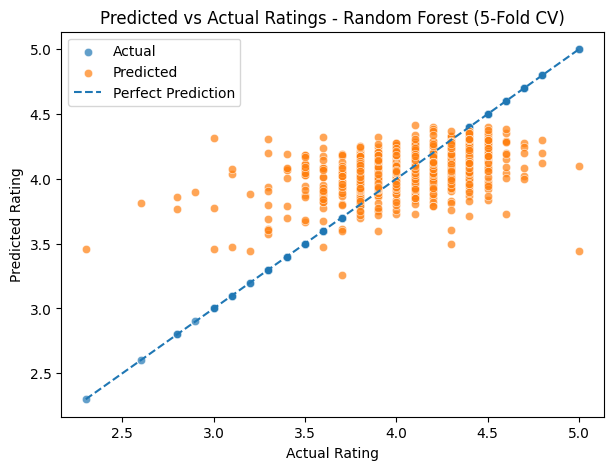

In [104]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_train,
    y=y_train,
    label='Actual',
    alpha=0.7
)

sns.scatterplot(
    x=y_train,
    y=y_pred_cv,
    label='Predicted',
    alpha=0.7
)

plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Predicted vs Actual Ratings - Random Forest (5-Fold CV)')
plt.legend()

plt.show()

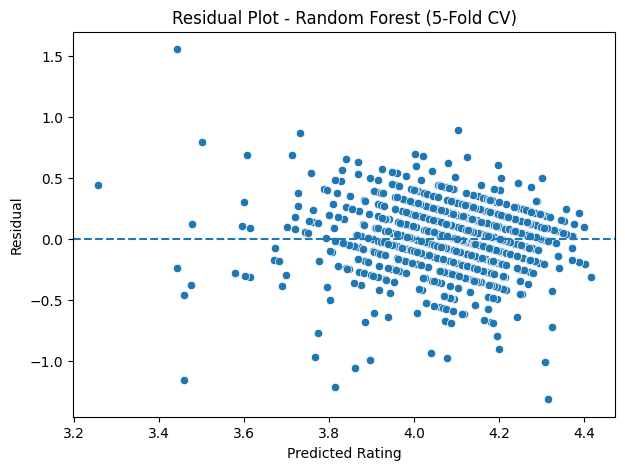

In [105]:
# Residuals from 5-fold CV
residuals = y_train - y_pred_cv

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_pred_cv,
    y=residuals
)

plt.axhline(0, linestyle='--')

plt.xlabel('Predicted Rating')
plt.ylabel('Residual')
plt.title('Residual Plot - Random Forest (5-Fold CV)')

plt.show()

### D1.4 Observation

The predicted ratings are mostly concentrated around **3.8–4.3**, while the actual ratings have a wider range. The model performs reasonably well for ratings around 4, but it tends to **overpredict lower ratings and underpredict some higher ratings**.

The residuals are mostly centered around **zero**, but there are some larger positive and negative residuals. Overall, the Random Forest captures the general pattern but has difficulty predicting extreme ratings accurately.


**D1.5** Retrain your best model **without** review-derived features and report the difference (links to C7).

In [106]:
# D1.5 - Random Forest without review-derived features

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# 1. Features without review-derived features
features_no_review = [
    'discount_amount',
    'log_actual_price',
    'log_discounted_price',
    'price_bucket',
    'log_rating_count',
    'is_popular',
    'rating_count_rank_in_category',
    'category_depth',
    'main_category',
    'sub_category_grouped',
    'name_length',
    'about_length',
    'is_cable',
    'is_wireless'
]

X_no_review = df_clean[features_no_review]
y_no_review = df_clean['rating']


# 2. Train-test split
X_train_nr, X_test_nr, y_train_nr, y_test_nr = train_test_split(
    X_no_review,
    y_no_review,
    test_size=0.20,
    random_state=42
)


# 3. Numerical and categorical features
numerical_features_nr = [
    'discount_amount',
    'log_actual_price',
    'log_discounted_price',
    'log_rating_count',
    'is_popular',
    'rating_count_rank_in_category',
    'category_depth',
    'name_length',
    'about_length',
    'is_cable',
    'is_wireless'
]

categorical_features_nr = [
    'main_category',
    'sub_category_grouped',
    'price_bucket'
]


# 4. Preprocessing
preprocessor_nr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_nr),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_nr)
    ]
)


# 5. Random Forest pipeline
rf_no_review = Pipeline([
    ('preprocessor', preprocessor_nr),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])


# 6. 5-fold CV
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

cv_results_nr = cross_validate(
    rf_no_review,
    X_train_nr,
    y_train_nr,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


# 7. CV results
mae_nr = -cv_results_nr['test_MAE'].mean()
rmse_nr = -cv_results_nr['test_RMSE'].mean()
r2_nr = cv_results_nr['test_R2'].mean()

print("Random Forest without review-derived features - 5-Fold CV")
print(f"MAE  : {mae_nr:.4f}")
print(f"RMSE : {rmse_nr:.4f}")
print(f"R²   : {r2_nr:.4f}")

Random Forest without review-derived features - 5-Fold CV
MAE  : 0.1837
RMSE : 0.2655
R²   : 0.1438


**Observation:**

Removing the review-derived features slightly worsened the model's performance. MAE increased from 0.1764 to 0.1837, RMSE increased from 0.2535 to 0.2655, and R² decreased from 0.2195 to 0.1438. This shows that review-derived features contain useful information for predicting ratings. However, these features may cause target leakage for a new product because reviews are generated after customer interaction. Therefore, they should be excluded when the objective is to predict the rating of a new listing.

## D2. Classification: predict `high_rated` (10 marks)

**D2.1** Define `high_rated = 1 if rating >= 4.2 else 0` (or justify a different threshold). Report the class balance.

In [107]:
df_clean['high_rated'] = (df_clean['rating'] >= 4.2).astype(int)

In [108]:
df_clean.groupby('high_rated')['product_id'].count()

high_rated
0    741
1    636
Name: product_id, dtype: int64

**Observation:**  
A product is classified as `high_rated = 1` if its rating is **4.2 or above**, otherwise `high_rated = 0`.

The class distribution is:

- **0 (Rating < 4.2):** 741 observations (**53.8%**)
- **1 (Rating ≥ 4.2):** 636 observations (**46.2%**)

The classes are fairly balanced, with a slightly higher number of products below 4.2.

**D2.2** Baseline: majority-class classifier.

In [109]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier

# Create binary target
df_clean['high_rated'] = (df_clean['rating'] >= 4.2).astype(int)

# X and y for classification
X_class = df_clean[features_no_review]
y_class = df_clean['high_rated']

# 5-fold Stratified CV
cv_class = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Majority-class baseline
baseline_clf = DummyClassifier(
    strategy='most_frequent',
    random_state=42
)

# 5-fold CV accuracy
cv_scores_baseline = cross_val_score(
    baseline_clf,
    X_class,
    y_class,
    cv=cv_class,
    scoring='accuracy',
    n_jobs=-1
)

print("Majority class:", y_class.mode()[0])
print("5-Fold CV Accuracy:", cv_scores_baseline.mean())
print("CV Accuracy Std:", cv_scores_baseline.std())

Majority class: 0
5-Fold CV Accuracy: 0.5381264822134387
CV Accuracy Std: 0.0011477554297344551


**D2.3** Train Logistic Regression and Random Forest Classifier (or Decision Tree).

In [110]:
# D2.3 - Logistic Regression and Random Forest Classifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd


# --------------------------------------------------
# 1. Features
# --------------------------------------------------

features_class = [
    'discount_amount',
    'log_actual_price',
    'log_discounted_price',
    'price_bucket',
    'log_rating_count',
    'is_popular',
    'rating_count_rank_in_category',
    'category_depth',
    'main_category',
    'sub_category_grouped',
    'name_length',
    'about_length',
    'is_cable',
    'is_wireless'
]

X_class = df_clean[features_class]
y_class = df_clean['high_rated']


# --------------------------------------------------
# 2. Train-test split
# --------------------------------------------------

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)


# --------------------------------------------------
# 3. Numerical features
# --------------------------------------------------

numerical_features_class = [
    'discount_amount',
    'log_actual_price',
    'log_discounted_price',
    'log_rating_count',
    'is_popular',
    'rating_count_rank_in_category',
    'category_depth',
    'name_length',
    'about_length',
    'is_cable',
    'is_wireless'
]


# --------------------------------------------------
# 4. Categorical features
# --------------------------------------------------

categorical_features_class = [
    'main_category',
    'sub_category_grouped',
    'price_bucket'
]


# --------------------------------------------------
# 5. Preprocessing
# --------------------------------------------------

preprocessor_class = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_class),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_class)
    ]
)


# --------------------------------------------------
# 6. Logistic Regression pipeline
# --------------------------------------------------

logistic_model = Pipeline([
    ('preprocessor', preprocessor_class),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


# --------------------------------------------------
# 7. Random Forest pipeline
# --------------------------------------------------

rf_classifier = Pipeline([
    ('preprocessor', preprocessor_class),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])


# --------------------------------------------------
# 8. 5-Fold Stratified Cross-Validation
# --------------------------------------------------

cv_class = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# --------------------------------------------------
# 9. Evaluation metrics
# --------------------------------------------------

scoring_class = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1': 'f1',
    'ROC-AUC': 'roc_auc'
}


# --------------------------------------------------
# 10. Cross-validation - Logistic Regression
# --------------------------------------------------

cv_logistic = cross_validate(
    logistic_model,
    X_class,
    y_class,
    cv=cv_class,
    scoring=scoring_class,
    n_jobs=-1
)


# --------------------------------------------------
# 11. Cross-validation - Random Forest
# --------------------------------------------------

cv_rf = cross_validate(
    rf_classifier,
    X_class,
    y_class,
    cv=cv_class,
    scoring=scoring_class,
    n_jobs=-1
)


**D2.4** Report accuracy, precision, recall, F1 and ROC-AUC; show the confusion matrix and ROC curve. Why is accuracy alone misleading here?

In [111]:
# --------------------------------------------------
# 12. Create comparison table
# --------------------------------------------------

classification_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy': [
        cv_logistic['test_Accuracy'].mean(),
        cv_rf['test_Accuracy'].mean()
    ],

    'Precision': [
        cv_logistic['test_Precision'].mean(),
        cv_rf['test_Precision'].mean()
    ],

    'Recall': [
        cv_logistic['test_Recall'].mean(),
        cv_rf['test_Recall'].mean()
    ],

    'F1': [
        cv_logistic['test_F1'].mean(),
        cv_rf['test_F1'].mean()
    ],

    'ROC-AUC': [
        cv_logistic['test_ROC-AUC'].mean(),
        cv_rf['test_ROC-AUC'].mean()
    ]
})


# --------------------------------------------------
# 13. Display results
# --------------------------------------------------

classification_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.660817,0.650668,0.584879,0.615155,0.717636
1,Random Forest,0.713138,0.709654,0.644660,0.675078,0.799129


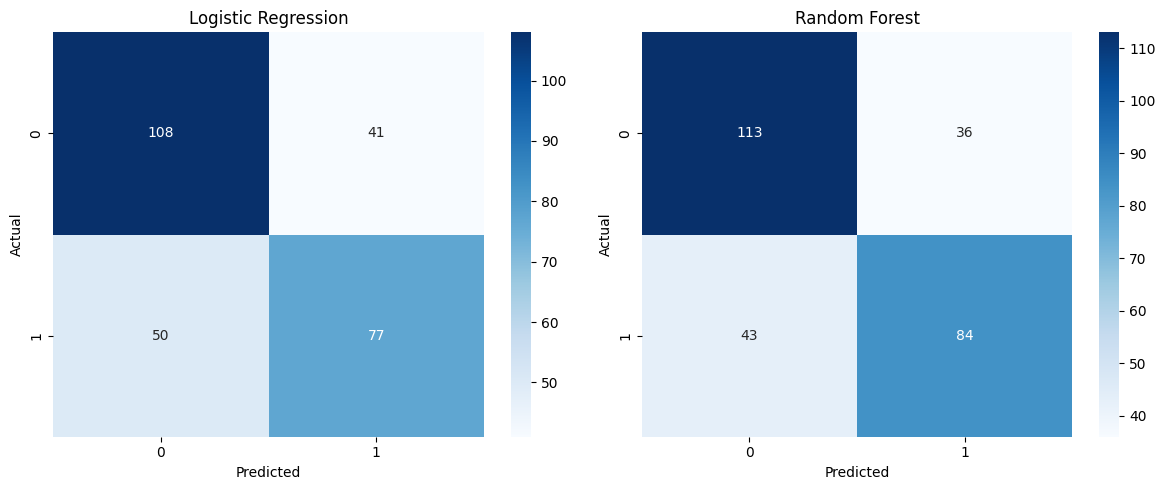

In [112]:
# Fit models on training data

logistic_model.fit(X_train_class, y_train_class)
rf_classifier.fit(X_train_class, y_train_class)

# Predictions on test data

y_pred_logistic = logistic_model.predict(X_test_class)
y_pred_rf_class = rf_classifier.predict(X_test_class)

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_logistic = confusion_matrix(
    y_test_class,
    y_pred_logistic
)

cm_rf = confusion_matrix(
    y_test_class,
    y_pred_rf_class
)

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)

axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

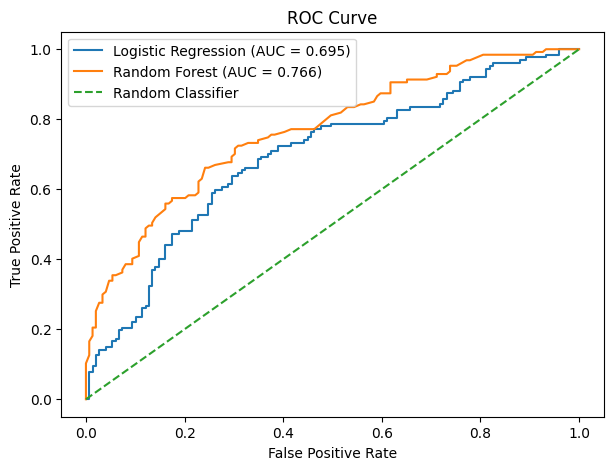

In [113]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability predictions on the test set
y_prob_logistic = logistic_model.predict_proba(X_test_class)[:, 1]
y_prob_rf = rf_classifier.predict_proba(X_test_class)[:, 1]

# ROC curves
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test_class,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test_class,
    y_prob_rf
)

# AUC
auc_logistic = roc_auc_score(
    y_test_class,
    y_prob_logistic
)

auc_rf = roc_auc_score(
    y_test_class,
    y_prob_rf
)

# Plot
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f'Logistic Regression (AUC = {auc_logistic:.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

**Observation:**  
Accuracy alone can be misleading because it only measures the overall proportion of correct predictions. It does not show how well the model identifies each class. Therefore, precision, recall, F1-score, confusion matrix and ROC-AUC are also used to evaluate the classification models.

## D3. Interpretation (3 marks)

**D3.1** Show the top 10 features by Random Forest (or permutation) importance and the largest logistic-regression coefficients. Do they match what you expected from Part B?

In [114]:
# Get feature names after preprocessing
feature_names = logistic_model.named_steps['preprocessor'].get_feature_names_out()

# ---------------- Random Forest Importance ----------------
rf_importance = rf_classifier.named_steps['model'].feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

print("Top 10 Random Forest Features:")
display(rf_importance_df.head(10))


# ---------------- Logistic Regression Coefficients ----------------
logistic_coef = logistic_model.named_steps['model'].coef_[0]

logistic_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': logistic_coef
})

# Largest coefficients by absolute value
logistic_top10 = logistic_coef_df.loc[
    logistic_coef_df['Coefficient'].abs().sort_values(ascending=False).index
].head(10)

print("Top 10 Logistic Regression Coefficients:")
display(logistic_top10)

Top 10 Random Forest Features:


,Feature,Importance
5,num__rating_count_rank_in_category,0.111019
3,num__log_rating_count,0.107202
0,num__discount_amount,0.106346
2,num__log_discounted_price,0.102721
1,num__log_actual_price,0.096289
8,num__about_length,0.094938
7,num__name_length,0.082867
6,num__category_depth,0.034552
11,cat__main_category_Computers&Accessories,0.020178
41,cat__sub_category_grouped_Other,0.018938


Top 10 Logistic Regression Coefficients:


,Feature,Coefficient
29,cat__sub_category_grouped_In-Ear,-1.910479
49,cat__sub_category_grouped_Smartphones,-1.597271
38,cat__sub_category_grouped_Mice,1.521547
22,cat__sub_category_grouped_EggBoilers,1.464805
26,cat__sub_category_grouped_GraphicTablets,-1.326181
46,cat__sub_category_grouped_ScreenProtectors,1.027203
39,cat__sub_category_grouped_MicroSD,0.952997
17,cat__main_category_OfficeProducts,0.949560
36,cat__sub_category_grouped_LaundryBaskets,-0.904119
20,cat__sub_category_grouped_DigitalKitchenScales,0.896696


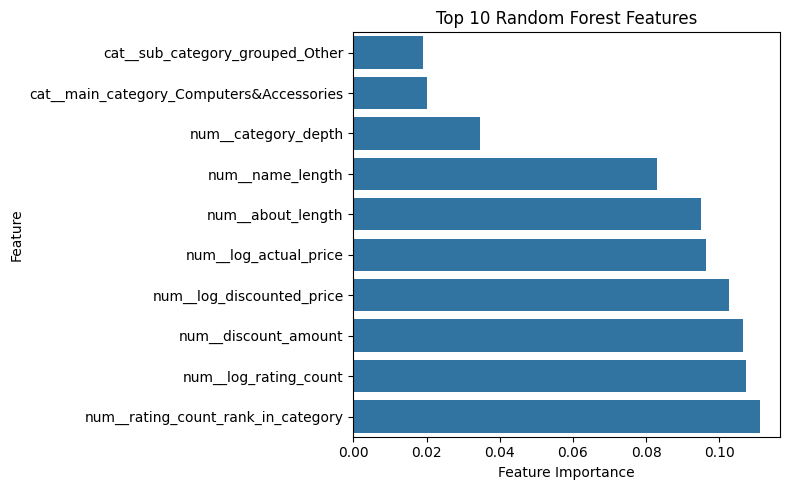

In [115]:
plt.figure(figsize=(8,5))

top10_rf = rf_importance_df.head(10).sort_values('Importance')

sns.barplot(
    data=top10_rf,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Random Forest Features')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Observation:**

The Random Forest identifies `rating_count_rank_in_category`, `log_rating_count`, `discount_amount`, and the price-related features as the most important predictors. This is broadly consistent with Part B, where we observed strong skewness in `rating_count` and a strong relationship between actual and discounted prices. Category-related features also appear among the important variables.

The Logistic Regression coefficients are mainly associated with specific sub-categories such as `In-Ear`, `Smartphones`, `Mice`, and `EggBoilers`. This suggests that the effect of product category can differ substantially across sub-categories.

Overall, the results are broadly consistent with Part B: **price, popularity, and category were identified as important factors**, although the exact features differ between Random Forest and Logistic Regression because the two models capture relationships differently.

**D4 (optional).** Tune one model with `GridSearchCV` (≤ 20 combinations) and report the gain over defaults.

In [116]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Random Forest inside the same preprocessing pipeline
rf_tuned_pipeline = Pipeline([
    ('preprocessor', preprocessor_class),
    ('model', RandomForestClassifier(random_state=42))
])

# 16 combinations = 2 × 2 × 2 × 2
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_tuned_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_class, y_train_class)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV ROC-AUC:
0.8122308878340434


In [117]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_class)
y_prob_tuned = best_rf.predict_proba(X_test_class)[:, 1]

tuned_results = {
    'Accuracy': accuracy_score(y_test_class, y_pred_tuned),
    'Precision': precision_score(y_test_class, y_pred_tuned),
    'Recall': recall_score(y_test_class, y_pred_tuned),
    'F1': f1_score(y_test_class, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test_class, y_prob_tuned)
}

tuned_results

{'Accuracy': 0.7137681159420289,
 'Precision': 0.7,
 'Recall': 0.6614173228346457,
 'F1': 0.680161943319838,
 'ROC-AUC': 0.7663689689795488}

In [118]:
default_results = {
    'Accuracy': accuracy_score(y_test_class, y_pred_rf_class),
    'Precision': precision_score(y_test_class, y_pred_rf_class),
    'Recall': recall_score(y_test_class, y_pred_rf_class),
    'F1': f1_score(y_test_class, y_pred_rf_class),
    'ROC-AUC': roc_auc_score(
        y_test_class,
        rf_classifier.predict_proba(X_test_class)[:, 1]
    )
}

comparison = pd.DataFrame({
    'Default Random Forest': default_results,
    'Tuned Random Forest': tuned_results
})

comparison['Gain'] = (
    comparison['Tuned Random Forest']
    - comparison['Default Random Forest']
)

comparison

,Default Random Forest,Tuned Random Forest,Gain
Accuracy,0.713768,0.713768,0.0
Precision,0.700000,0.700000,0.0
Recall,0.661417,0.661417,0.0
F1,0.680162,0.680162,0.0
ROC-AUC,0.766369,0.766369,0.0


**Observation:**

GridSearchCV was used to tune the Random Forest using 16 parameter combinations and 5-fold cross-validation. However, the tuned Random Forest produced exactly the same results as the default model on the test set.

The Accuracy (0.714), Precision (0.700), Recall (0.661), F1-score (0.680), and ROC-AUC (0.766) remained unchanged. Therefore, **there was no measurable gain from tuning the selected hyperparameters** for this dataset.

This suggests that the default Random Forest was already performing similarly to the best combination found by the grid search.

# Part E — Written summary (10 marks)
Write a summary (max 400 words) for a category manager with no data-science background, covering:
1. The three most useful findings about pricing, discounts and ratings, with numbers.
2. How well rating can be predicted compared with the naive baseline, in plain words.
3. Two limitations of the dataset and one extra data source you would ask for.

Also submit this as `summary.pdf`.

**Your summary:**

_Write here._

# Bonus (pick any, max 10 marks)
- **Clustering (5):** K-Means on scaled price, discount and popularity features; profile each cluster in one line.
- **TF-IDF model (5):** Predict `high_rated` from `review_content` with TF-IDF + Logistic Regression; list the 15 most positive and negative terms.
- **Discount model (5):** Predict `discount_percentage` from category, price and popularity. What drives deep discounts?
- **Dashboard (5):** A small interactive Plotly or Streamlit view of category-level metrics.

In [119]:
cluster_features = [
    'log_actual_price',
    'discount_percentage',
    'log_rating_count',
    'rating',
    'discount_amount'
]

X_cluster = df_clean[cluster_features].copy()

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(X_cluster)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

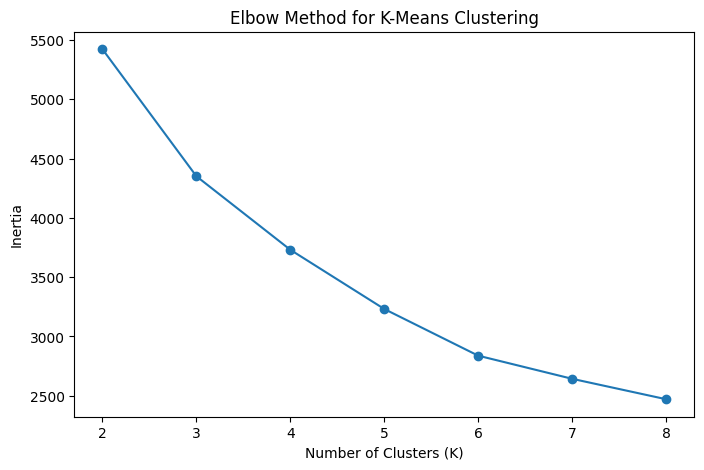

In [121]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(2, 9)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means Clustering')
plt.xticks(K)
plt.show()

In [122]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_clean['cluster'] = kmeans.fit_predict(X_cluster_scaled)

df_clean['cluster'].value_counts().sort_index()

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.



cluster
0    398
1    345
2    171
3    463
Name: count, dtype: int64

In [123]:
cluster_profile = df_clean.groupby('cluster').agg(
    number_of_products=('product_id', 'count'),
    avg_actual_price=('actual_price', 'mean'),
    avg_discount=('discount_percentage', 'mean'),
    avg_rating_count=('rating_count', 'mean'),
    avg_rating=('rating', 'mean'),
    avg_discount_amount=('discount_amount', 'mean')
).round(2)

cluster_profile

,number_of_products,avg_actual_price,avg_discount,avg_rating_count,avg_rating,avg_discount_amount
cluster,,,,,,
0,398,3004.25,0.22,17150.83,4.19,642.91
1,345,2056.01,0.59,1188.18,3.84,1148.45
2,171,28110.94,0.44,12856.08,4.18,11568.41
3,463,2260.58,0.61,32372.00,4.16,1387.71


In [124]:
cluster_median = df_clean.groupby('cluster').agg(
    median_actual_price=('actual_price', 'median'),
    median_discount=('discount_percentage', 'median'),
    median_rating_count=('rating_count', 'median'),
    median_rating=('rating', 'median'),
    median_discount_amount=('discount_amount', 'median')
).round(2)

cluster_median

,median_actual_price,median_discount,median_rating_count,median_rating,median_discount_amount
cluster,,,,,
0,1599.0,0.23,6739.0,4.2,350.0
1,1200.0,0.58,465.0,3.9,800.0
2,20999.0,0.41,7109.0,4.2,8491.0
3,1499.0,0.60,12958.0,4.2,891.0


| Cluster       | Profile                                                                                                                            |
| ------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| **Cluster 0** | **Moderately priced, low-discount products** with median price ₹1,599, 23% discount, and moderate popularity.                      |
| **Cluster 1** | **Lower-priced, heavily discounted, low-popularity products** with median price ₹1,200, 58% discount, and only 465 median ratings. |
| **Cluster 2** | **High-priced products** with median price ₹20,999 and the largest absolute discount, while maintaining high ratings.              |
| **Cluster 3** | **Affordable, heavily discounted, highly popular products** with median price ₹1,499, 60% discount, and 12,958 median ratings.     |


**Cluster Interpretation:**

K-Means divides the products into four distinct groups based on price, discount, popularity, and rating. Cluster 0 contains moderately priced products with relatively low discounts and moderate popularity. Cluster 1 represents lower-priced products with high discounts but low popularity. Cluster 2 consists mainly of expensive products with large absolute discounts and high ratings. Cluster 3 contains affordable, heavily discounted, and highly popular products. Overall, the clusters show clear differences in product price, discounting strategy, and popularity.

# PLotly

In [125]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

dashboard_data = df_clean.groupby('main_category').agg(
    number_of_products=('product_id', 'count'),
    median_actual_price=('actual_price', 'median'),
    median_discount=('discount_percentage', 'median'),
    mean_rating=('rating', 'mean'),
    total_rating_count=('rating_count', 'sum')
).reset_index()

dashboard_data

,main_category,number_of_products,median_actual_price,median_discount,mean_rating,total_rating_count
0,Car&Motorbike,1,4000.0,0.420,3.800000,1118
1,Computers&Accessories,389,999.0,0.570,4.153985,6560117
2,Electronics,502,3199.5,0.530,4.076693,14603620
3,Health&PersonalCare,1,1900.0,0.530,4.000000,3663
4,Home&Kitchen,448,2000.0,0.415,4.040848,2991069
5,HomeImprovement,2,799.0,0.575,4.250000,8566
6,MusicalInstruments,2,1347.0,0.460,3.900000,88882
7,OfficeProducts,31,210.0,0.050,4.309677,149675
8,Toys&Games,1,150.0,0.000,4.300000,15867


In [126]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create dashboard
fig = make_subplots(
    rows=2,
    cols=2,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "bar"}, {"type": "bar"}]
    ],
    subplot_titles=(
        "Number of Products",
        "Mean Rating",
        "Median Actual Price by Category",
        "Median Discount by Category"
    )
)

# Initial category
initial_category = dashboard_data.iloc[0]

# KPI 1: Number of products
fig.add_trace(
    go.Indicator(
        mode="number",
        value=initial_category["number_of_products"],
        title={"text": "Products"}
    ),
    row=1, col=1
)

# KPI 2: Mean rating
fig.add_trace(
    go.Indicator(
        mode="number",
        value=initial_category["mean_rating"],
        number={"valueformat": ".2f"},
        title={"text": "Mean Rating"}
    ),
    row=1, col=2
)

# Chart 1: Median price
fig.add_trace(
    go.Bar(
        x=dashboard_data["main_category"],
        y=dashboard_data["median_actual_price"],
        name="Median Price"
    ),
    row=2, col=1
)

# Chart 2: Median discount
fig.add_trace(
    go.Bar(
        x=dashboard_data["main_category"],
        y=dashboard_data["median_discount"] * 100,
        name="Median Discount"
    ),
    row=2, col=2
)

# Dropdown
buttons = []

for _, row in dashboard_data.iterrows():

    buttons.append(
        dict(
            label=row["main_category"],
            method="update",
            args=[
                {
                    "value": [
                        row["number_of_products"],
                        row["mean_rating"]
                    ]
                },
                {
                    "title": {
                        "text": f"Amazon Product Dashboard — {row['main_category']}"
                    }
                }
            ]
        )
    )

fig.update_layout(
    title="Amazon Product Dashboard",
    height=750,
    showlegend=False,
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.0,
            y=1.15,
            xanchor="right",
            yanchor="top"
        )
    ]
)

fig.update_xaxes(tickangle=45)

fig.show()

# AI-use disclosure
Describe any AI tools you used and for what.

